# Chapter 14 — On-Board Data Processing: Hands-On Python Practice
## *Fundamentals of the Internet of Things*
**Oleksandr Kuznetsov** · eCampus University, Novedrate (CO), Italy

---

> **How to use this notebook.** The four exercises are designed to be run
> in order: they intentionally reuse two shared synthetic test signals,
> built by the generator functions defined in Setup, rather than each
> starting from scratch. Read the background for an exercise, run its
> cells, study the plots, then try the challenge tasks before moving on.
> All exercises run in Google Colab with no additional hardware and use
> only NumPy, SciPy, and Matplotlib.

| Exercise | Topic | Key technique |
|----------|-------|----------------|
| 14.1 | Denoising a slowly varying sensor signal | Causal SMA, EMA, median, and scalar Kalman filters |
| 14.2 | Digital low-pass filtering to a spec | Butterworth vs. Chebyshev Type I IIR design |
| 14.3 | Detecting transient outliers on-board | Sliding z-score, Hampel identifier, causal difference-domain MAD |
| 14.4 | Reducing what gets transmitted | Send-on-delta compression and FFT band-energy feature extraction |

**Signal A** (Exercises 14.1, 14.3, 14.4a) is a generic, moderately fast
analogue sensor channel sampled at 100 Hz, carrying two tones, a slow
drift, an additive level step, and Gaussian noise. **Signal B**
(Exercises 14.2, 14.4b) is a 500 Hz vibration channel with two mechanical
harmonics and 50 Hz mains-frequency interference, of the kind an
accelerometer on a motor housing would produce. Both are built by fixed,
seeded generator functions, so every reader gets the same numbers and
figures shown in this chapter.

---
## Setup

In [1]:
# -- Setup --------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import (lfilter, buttord, cheb1ord, butter, cheby1,
                           sosfilt, sosfiltfilt, sosfreqz,
                           correlate, periodogram)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'lines.linewidth': 1.4,
})

def rmse(a, b):
    return np.sqrt(np.mean((np.asarray(a) - np.asarray(b))**2))

def generate_signal_a(seed=42):
    """Signal A: a 100 Hz analogue sensor channel with two tones, drift,
    an additive level step at t=5s, and Gaussian noise. Returns
    (t, raw, target) where target is the noise-free reference the
    filters in this chapter try to recover."""
    fs = 100.0
    t = np.arange(0, 10.0, 1/fs)
    rng = np.random.default_rng(seed)
    f1, f2 = 1.0, 4.0
    drift = 0.08 * t
    sigma_n = 0.5
    step_time, step_amp = 5.0, 1.5
    level_step = np.where(t < step_time, 0.0, step_amp)
    clean = 2.0*np.sin(2*np.pi*f1*t) + 0.5*np.sin(2*np.pi*f2*t)
    target = clean + drift + level_step
    raw = target + rng.normal(0, sigma_n, len(t))
    return t, raw, target, sigma_n

def generate_signal_b(seed=7, duration=3.0, a2=1.0):
    """Signal B: a 500 Hz vibration channel with two mechanical harmonics
    (15 Hz, 30 Hz) and 50 Hz mains interference. a2 sets the 30 Hz
    harmonic amplitude (used in Exercise 14.4b to simulate a developing
    fault). Returns (t, raw, clean_vibration)."""
    fs = 500.0
    t = np.arange(0, duration, 1/fs)
    rng = np.random.default_rng(seed)
    f1, f2, fm = 15.0, 30.0, 50.0
    a1, am, sigma = 2.0, 1.5, 0.1
    clean = a1*np.sin(2*np.pi*f1*t) + a2*np.sin(2*np.pi*f2*t)
    mains = am*np.sin(2*np.pi*fm*t)
    raw = clean + mains + rng.normal(0, sigma, len(t))
    return t, raw, clean

print("Environment ready.")

Environment ready.


---
## Exercise 14.1 — Denoising a Slowly Varying Sensor Signal

### Background

A large share of the readings an IoT node collects change on a timescale
of seconds, not milliseconds, yet the front-end ADC is usually clocked
much faster than that, either because the sensor datasheet requires it
or because the design was inherited from a faster channel on the same
board. The result is a stream of samples in which genuine signal motion
is buried in wideband measurement noise. Removing that noise on the node
itself, rather than shipping raw samples to a gateway and filtering them
there, saves radio airtime and lets the node react to real changes
without waiting for a round trip.

This exercise compares four classic recursive/short-window filters for
that job: the simple moving average (SMA), the exponential moving
average (EMA), the median filter, and a scalar Kalman filter with a
constant-value process model (Section 14.2). All four are implemented in
their **causal** form, using only the current and past samples, because
that is the only form a live, streaming sensor node can actually run; a
centred (non-causal) moving average, which also uses future samples, is
convenient for offline analysis but cannot exist on a device reading
data in real time.

### Signal model

Signal A combines two sinusoidal tones at 1 Hz and 4 Hz, a slow linear
drift, a genuine **additive level step** of 1.5 units at $t=5$ s
(representing an external event such as a load or setpoint change), and
Gaussian noise. The step is additive rather than a change in the tones'
amplitude, so it produces a real, unambiguous discontinuity in the
target signal that a filter's step response can be measured against.

In [2]:
# -- Exercise 14.1: signal and four causal denoising filters --------------
t_a, raw_a, target_a, sigma_n = generate_signal_a(seed=42)
fs_a = 100.0
N_a = len(t_a)

def sma_causal(x, M):
    """Causal simple moving average, implemented as an FIR filter."""
    return lfilter(np.ones(M)/M, [1.0], x)

def ema(x, alpha):
    """Exponential moving average (first-order recursive IIR filter)."""
    y = np.zeros_like(x)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha*x[i] + (1-alpha)*y[i-1]
    return y

def median_causal(x, M):
    """Causal median filter: median of the current sample and the M-1 before it."""
    n = len(x)
    y = np.zeros(n)
    for i in range(n):
        lo = max(0, i-M+1)
        y[i] = np.median(x[lo:i+1])
    return y

def kalman_1d(x, Q, R):
    """Scalar Kalman filter, constant-value process model."""
    n = len(x)
    y = np.zeros(n)
    P, xhat = 1.0, x[0]
    for i in range(n):
        P = P + Q                      # predict
        K = P / (P + R)                # Kalman gain
        xhat = xhat + K*(x[i]-xhat)    # update
        P = (1 - K) * P
        y[i] = xhat
    return y

M_sma, alpha_ema, M_med = 3, 0.4, 3
Q_kal, R_kal = 0.05, sigma_n**2

y_sma = sma_causal(raw_a, M_sma)
y_ema = ema(raw_a, alpha_ema)
y_med = median_causal(raw_a, M_med)
y_kal = kalman_1d(raw_a, Q_kal, R_kal)

idx_step = np.searchsorted(t_a, 5.0)
pre_step  = t_a < 5.0
trans     = slice(idx_step, idx_step + 30)          # 0-300 ms after the step
steady_post = slice(idx_step + 150, N_a)             # 1.5-5 s after the step

print(f"{'Method':<18s}{'RMSE full':>10s}{'RMSE pre-step':>15s}{'RMSE transition':>17s}{'RMSE steady-post':>18s}{'Peak err (trans.)':>19s}")
for name, y in [('Raw (unfiltered)', raw_a), (f'SMA (M={M_sma})', y_sma),
                (f'EMA (alpha={alpha_ema})', y_ema), (f'Median (M={M_med})', y_med),
                (f'Kalman (Q={Q_kal})', y_kal)]:
    print(f"{name:<18s}{rmse(y,target_a):>10.4f}{rmse(y[pre_step],target_a[pre_step]):>15.4f}"
          f"{rmse(y[trans],target_a[trans]):>17.4f}{rmse(y[steady_post],target_a[steady_post]):>18.4f}"
          f"{np.max(np.abs(y[trans]-target_a[trans])):>19.4f}")

Method             RMSE full  RMSE pre-step  RMSE transition  RMSE steady-post  Peak err (trans.)
Raw (unfiltered)      0.4946         0.4795           0.5710            0.5058             1.4823
SMA (M=3)             0.3271         0.3127           0.4655            0.3488             1.6016
EMA (alpha=0.4)       0.3176         0.2989           0.4846            0.3394             1.3343
Median (M=3)          0.3761         0.3506           0.6037            0.3980             2.4983
Kalman (Q=0.05)       0.3258         0.3043           0.5329            0.3468             1.4798


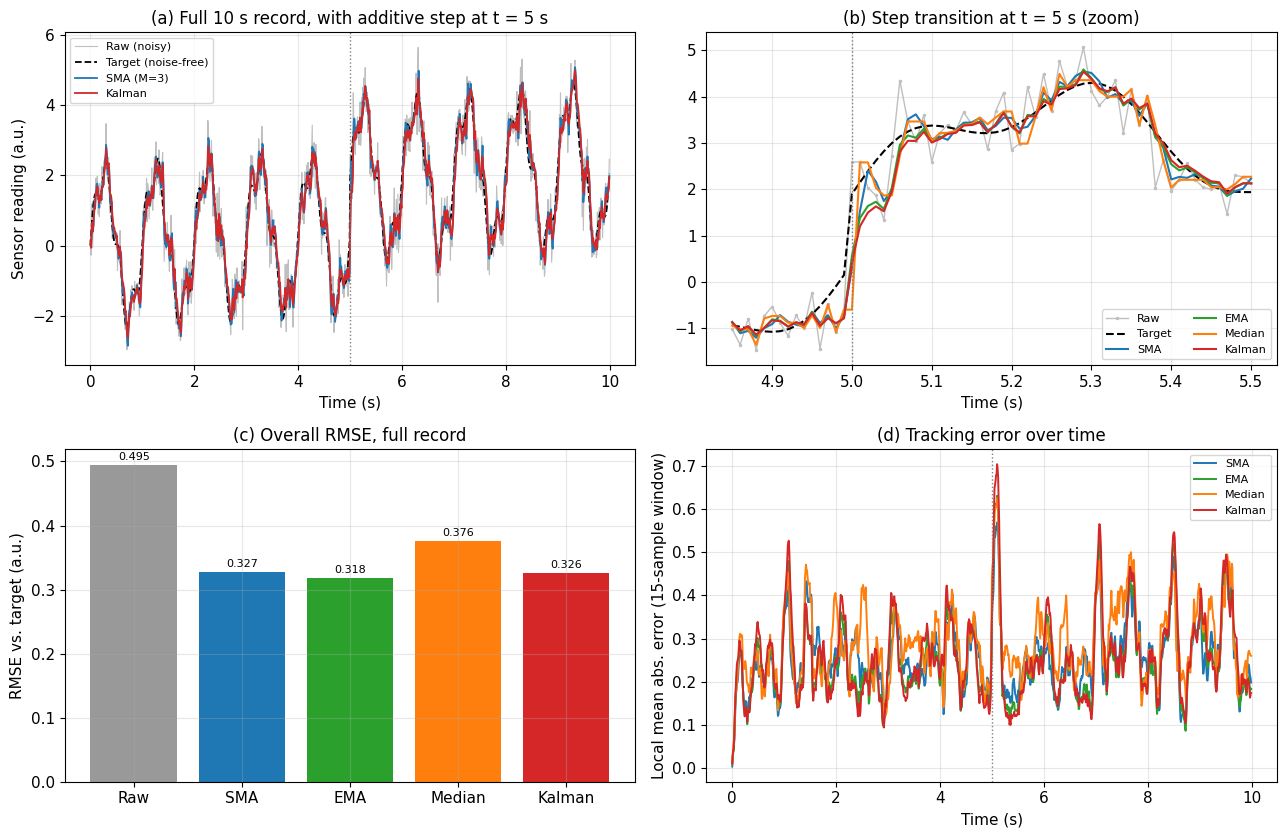

In [3]:
# -- Figure 14.1: filter comparison ---------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))

ax = axes[0,0]
ax.plot(t_a, raw_a, color='0.75', lw=0.8, label='Raw (noisy)')
ax.plot(t_a, target_a, 'k--', lw=1.3, label='Target (noise-free)')
ax.plot(t_a, y_sma, color='tab:blue', lw=1.3, label=f'SMA (M={M_sma})')
ax.plot(t_a, y_kal, color='tab:red', lw=1.3, label='Kalman')
ax.axvline(5.0, color='gray', ls=':', lw=1)
ax.set_xlabel('Time (s)'); ax.set_ylabel('Sensor reading (a.u.)')
ax.set_title('(a) Full 10 s record, with additive step at t = 5 s')
ax.legend(fontsize=8, loc='upper left')

ax = axes[0,1]
zoom = (t_a >= 4.85) & (t_a <= 5.5)
ax.plot(t_a[zoom], raw_a[zoom], color='0.75', lw=1.0, marker='.', ms=3, label='Raw')
ax.plot(t_a[zoom], target_a[zoom], 'k--', lw=1.5, label='Target')
ax.plot(t_a[zoom], y_sma[zoom], color='tab:blue', lw=1.5, label='SMA')
ax.plot(t_a[zoom], y_ema[zoom], color='tab:green', lw=1.5, label='EMA')
ax.plot(t_a[zoom], y_med[zoom], color='tab:orange', lw=1.5, label='Median')
ax.plot(t_a[zoom], y_kal[zoom], color='tab:red', lw=1.5, label='Kalman')
ax.axvline(5.0, color='gray', ls=':', lw=1)
ax.set_xlabel('Time (s)'); ax.set_title('(b) Step transition at t = 5 s (zoom)')
ax.legend(fontsize=8, ncol=2)

ax = axes[1,0]
methods = ['Raw', 'SMA', 'EMA', 'Median', 'Kalman']
vals = [rmse(raw_a,target_a), rmse(y_sma,target_a), rmse(y_ema,target_a),
        rmse(y_med,target_a), rmse(y_kal,target_a)]
bars = ax.bar(methods, vals, color=['0.6','tab:blue','tab:green','tab:orange','tab:red'])
ax.set_ylabel('RMSE vs. target (a.u.)'); ax.set_title('(c) Overall RMSE, full record')
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.008, f'{v:.3f}', ha='center', fontsize=8)

ax = axes[1,1]
win = 15
smooth_err = lambda e: lfilter(np.ones(win)/win, [1.0], e)
for name, y, c in [('SMA', y_sma, 'tab:blue'), ('EMA', y_ema, 'tab:green'),
                    ('Median', y_med, 'tab:orange'), ('Kalman', y_kal, 'tab:red')]:
    ax.plot(t_a, smooth_err(np.abs(y-target_a)), color=c, label=name)
ax.axvline(5.0, color='gray', ls=':', lw=1)
ax.set_xlabel('Time (s)'); ax.set_ylabel(f'Local mean abs. error ({win}-sample window)')
ax.set_title('(d) Tracking error over time'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_14_1_filters.png', dpi=150, bbox_inches='tight')
plt.show()

### Analysis

Over the full ten-second record, EMA has the lowest RMSE (0.318),
narrowly ahead of Kalman (0.326) and SMA (0.327), with the median filter
trailing (0.376). Splitting the record around the step complicates that
ranking rather than simply reversing it. In the transition window (the
first 300 ms after $t=5$ s), SMA is the most accurate (RMSE 0.466),
followed by EMA (0.485) and Kalman (0.533), with the median filter
clearly the least accurate (0.604) -- so EMA is *not* the worst
performer here, it is second-best, just no longer the outright winner it
was on the full record. Peak absolute error tells a related but not
identical story: EMA has the smallest single spike (1.33), Kalman the
next smallest (1.48), SMA a little larger (1.60), and the median filter
markedly the largest (2.50). Transition-window RMSE and peak error are
measuring different things -- one integrates the whole 300~ms window, the
other captures the single worst instant -- and here they do not quite
agree on which filter is "fastest." In the steady state well after the
step ($t=6.5$--$10$ s), the ranking reverts to EMA and Kalman ahead of
SMA, consistent with the pre-step half of the record.

Figure 14.1(b) shows part of the mechanism directly: SMA's short
3-sample window reaches the new level within one or two samples, while
EMA and Kalman visibly lag before settling. The median filter, despite
sharing the same 3-sample window as SMA, is not simply "just as fast":
a linear average blends old and new values smoothly as they move
through the window, so its output partway through a step is a
partial, intermediate value -- but a median instead reports whichever
value is in the *majority* within the window, with no partial blending
at all. For a 3-sample window straddling a step, the median can still
read the *old* level right up until the new value is in the majority,
and then jump to the new level all at once. That all-or-nothing
behaviour is exactly why the median filter has the largest peak error
and the worst transition-window RMSE of the four methods here, even
though it also reaches the fully-settled new level about as quickly as
SMA does. Response speed, transient accuracy, and steady-state noise
rejection are three related but genuinely different properties, and no
single filter in this exercise wins on all three at once.

The full-record RMSE numbers alone would have suggested EMA is simply
"the best" filter here -- a conclusion the transition-window breakdown
complicates without reversing it outright: EMA remains a strong, though
not the fastest, performer around the step. Which filter is actually
preferable depends on whether the application cares more about a low
noise floor between events or about the single worst error during a
genuine change.

> **Key takeaway.** A recursive filter's steady-state noise rejection
> and its speed of response to a genuine change are related but
> different axes, not one and the same. Reporting only a single,
> full-record RMSE can hide this; always check performance separately
> in steady state and around a known transition -- and, if the worst
> single error matters as much as the average one, check peak error
> too -- before picking a filter for a latency-sensitive application.

**Challenge tasks**

1. Increase the SMA and median window sizes to $M=9$ and $M=15$ and
   recompute the results table. At what window size does the 4 Hz tone
   itself start to visibly attenuate?
2. Replace the constant-value Kalman process model with a
   constant-velocity model (state $[\hat{x}, \hat{v}]$). Does it reduce
   the lag visible in Figure 14.1(b), and does it change the steady-state
   RMSE before and after the step?
3. Sweep $\alpha$ for the EMA filter from 0.05 to 0.9 and plot RMSE
   (full record, transition window, and steady-post window) vs. $\alpha$.
   Is there a value of $\alpha$ that is simultaneously competitive on all
   three metrics, or is the trade-off unavoidable?
4. Add a second, larger amplitude step at $t=8$ s and compare the peak
   transition error and transition-window RMSE of all four filters on
   this new event.

---
## Exercise 14.2 — Specification-Driven IIR Low-Pass Design: Butterworth vs. Chebyshev

### Background

The filters in Exercise 14.1 remove broadband noise by averaging over a
short window, but they offer only limited, indirectly controlled
frequency selectivity: an SMA has spectral nulls at multiples of
$f_s/M$, and an EMA rolls off smoothly from DC, but neither one can be
handed an independent passband/stopband specification and be relied on
to meet it. Meeting a specification like "pass everything below 35 Hz,
reject anything at 50 Hz by at least 40 dB" calls for a filter designed
directly from that specification, which is the classical territory of
IIR filter design.

Two families dominate this territory. The **Butterworth** filter is
maximally flat in the passband, at the cost of a gentle roll-off: it
needs a higher order to reach a given stopband attenuation over a given
transition width. The **Chebyshev Type I** filter allows a small,
specified ripple in the passband in exchange for a steeper roll-off,
reaching the same specification at a lower order.
`scipy.signal.buttord` and `scipy.signal.cheb1ord` compute the
*minimum* order each family needs to meet a four-number specification
$(f_p, f_{stop}, r_p, r_s)$: no more than $r_p$ dB down up to $f_p$, and
at least $r_s$ dB of attenuation by $f_{stop}$.

**Relation to Chapter 13.** The anti-aliasing filter in Chapter 13 is an
*analogue* filter placed *before* the ADC, whose job is to guarantee the
sampling theorem is not violated. The filter designed here is a
*digital* filter applied *after* sampling, to already-correctly-acquired
data, as part of on-board processing — a different stage of the signal
chain with a different job: rejecting an out-of-band interferer that
survived acquisition, not preventing aliasing.

### Signal model and filter specification

Signal B is a 500 Hz vibration channel: two mechanical harmonics at
15 Hz and 30 Hz, a 50 Hz mains tone, and light measurement noise. The
design target is a lowpass filter that passes the mechanical content up
to 35 Hz with at most 1 dB of ripple, and attenuates the mains tone at
50 Hz by at least 40 dB.

In [4]:
# -- Exercise 14.2: signal and filter design -------------------------------
t_b, raw_b, clean_vib = generate_signal_b(seed=7, duration=3.0)
fs_b = 500.0
N_b = len(t_b)
nyq_b = fs_b / 2
f1_v, f2_v, f_mains = 15.0, 30.0, 50.0

fp, fstop, rp, rs = 35.0, 50.0, 1.0, 40.0          # design spec
wp, ws = fp/nyq_b, fstop/nyq_b

n_but, wn_but = buttord(wp, ws, rp, rs)
n_che, wn_che = cheb1ord(wp, ws, rp, rs)
sos_but = butter(n_but, wn_but, btype='low', output='sos')
sos_che = cheby1(n_che, rp, wn_che, btype='low', output='sos')

print(f"Butterworth: minimum order = {n_but}, cutoff = {wn_but*nyq_b:.2f} Hz")
print(f"Chebyshev I: minimum order = {n_che}, cutoff = {wn_che*nyq_b:.2f} Hz")
print(f"Order ratio (Butter/Cheby): {n_but/n_che:.2f}x")

w_resp, h_but = sosfreqz(sos_but, worN=8000, fs=fs_b)   # sosfreqz, not sos2tf+freqz:
_,      h_che = sosfreqz(sos_che, worN=8000, fs=fs_b)   # avoids converting a 15th-order SOS to (b,a)
db = lambda h: 20*np.log10(np.abs(h)+1e-20)
i50 = np.argmin(np.abs(w_resp-50))
print(f"Attenuation at 50 Hz: Butterworth {db(h_but)[i50]:.1f} dB, Chebyshev I {db(h_che)[i50]:.1f} dB "
      f"(spec required <= -{rs:.0f} dB)")

Butterworth: minimum order = 15, cutoff = 36.56 Hz
Chebyshev I: minimum order = 7, cutoff = 35.00 Hz
Order ratio (Butter/Cheby): 2.14x
Attenuation at 50 Hz: Butterworth -42.9 dB, Chebyshev I -44.0 dB (spec required <= -40 dB)


In [5]:
# -- Exercise 14.2: zero-phase vs. causal filtering, step response --------
y_but_ff = sosfiltfilt(sos_but, raw_b)     # zero-phase, offline reference only
y_che_ff = sosfiltfilt(sos_che, raw_b)
y_but_c  = sosfilt(sos_but, raw_b)         # causal, real-time-feasible
y_che_c  = sosfilt(sos_che, raw_b)

print(f"Zero-phase (filtfilt, OFFLINE REFERENCE ONLY) RMSE vs. clean signal: "
      f"raw={rmse(raw_b,clean_vib):.4f}  Butter={rmse(y_but_ff,clean_vib):.4f}  Cheby={rmse(y_che_ff,clean_vib):.4f}")

def group_delay_from_sos(sos, w_hz, fs):
    """Group delay estimated directly from sosfreqz's unwrapped phase,
    avoiding the sos-to-transfer-function conversion, which becomes
    numerically fragile for a filter of this order (Butterworth, order
    15)."""
    w_rad = np.asarray(w_hz) * (2*np.pi/fs)
    _, h = sosfreqz(sos, worN=w_rad)
    phase = np.unwrap(np.angle(h))
    return -np.gradient(phase, w_rad)   # samples

# Causal filtering delays the output. A single theoretical group-delay
# figure is not reliable here because the passband carries two tones
# (15 and 30 Hz) with different delays (see Figure 14.2d), so the delay
# actually used below is estimated empirically, by cross-correlating each
# causal output against the known clean signal -- the same approach a
# bench test would use with a reference channel.
skip = 300  # discard the filter's initial-condition transient
def estimate_delay(y, ref, max_lag=60):
    c = correlate(y[skip:], ref[skip:], mode='full')
    lags = np.arange(-(len(ref[skip:])-1), len(y[skip:]))
    valid = (lags >= 0) & (lags <= max_lag)
    return int(lags[valid][np.argmax(c[valid])])
d_but = estimate_delay(y_but_c, clean_vib)
d_che = estimate_delay(y_che_c, clean_vib)
delayed_rmse = lambda y, ref, d: rmse(y[skip+d:], ref[skip:len(ref)-d])
print(f"Causal (real-time) RMSE, delay-compensated: Butter={delayed_rmse(y_but_c,clean_vib,d_but):.4f} "
      f"(delay={d_but} samples, {d_but/fs_b*1000:.0f} ms)   "
      f"Cheby={delayed_rmse(y_che_c,clean_vib,d_che):.4f} (delay={d_che} samples, {d_che/fs_b*1000:.0f} ms)")

# Step response: overshoot and 2% settling time
step_in = np.ones(1000)
y_but_step = sosfilt(sos_but, step_in)
y_che_step = sosfilt(sos_che, step_in)
def settling_time(y, tol=0.02):
    idx = np.where(np.abs(y-1.0) > tol)[0]
    return (idx[-1]+1) if len(idx) else 0
st_but, st_che = settling_time(y_but_step), settling_time(y_che_step)
print(f"\nStep response: Butter overshoot={100*(y_but_step.max()-1):.1f}%, "
      f"settle(2%)={st_but} samples ({st_but/fs_b*1000:.0f} ms)")
print(f"               Cheby  overshoot={100*(y_che_step.max()-1):.1f}%, "
      f"settle(2%)={st_che} samples ({st_che/fs_b*1000:.0f} ms)")

sections_but, sections_che = int(np.ceil(n_but/2)), int(np.ceil(n_che/2))
print(f"\nCost per sample (direct-form-II-transposed biquads, ~9 flops each): "
      f"Butter={sections_but} sections~{9*sections_but} flops, "
      f"Cheby={sections_che} sections~{9*sections_che} flops")

Zero-phase (filtfilt, OFFLINE REFERENCE ONLY) RMSE vs. clean signal: raw=1.0637  Butter=0.0489  Cheby=0.1106
Causal (real-time) RMSE, delay-compensated: Butter=0.3761 (delay=22 samples, 44 ms)   Cheby=0.4036 (delay=15 samples, 30 ms)

Step response: Butter overshoot=20.3%, settle(2%)=66 samples (132 ms)
               Cheby  overshoot=12.4%, settle(2%)=74 samples (148 ms)

Cost per sample (direct-form-II-transposed biquads, ~9 flops each): Butter=8 sections~72 flops, Cheby=4 sections~36 flops


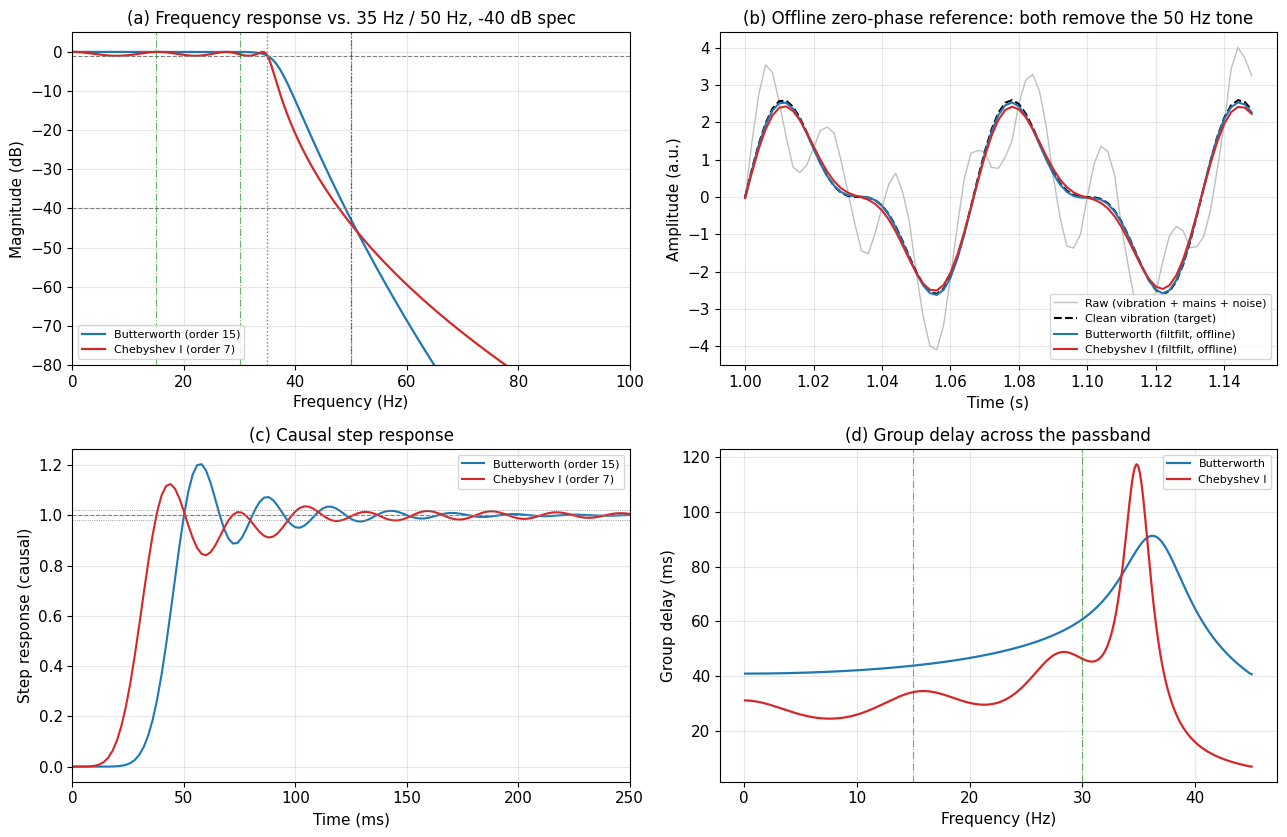

In [6]:
# -- Figure 14.2: filter design comparison --------------------------------
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))

ax = axes[0,0]
ax.plot(w_resp, db(h_but), color='tab:blue', lw=1.6, label=f'Butterworth (order {n_but})')
ax.plot(w_resp, db(h_che), color='tab:red', lw=1.6, label=f'Chebyshev I (order {n_che})')
ax.axvline(fp, color='gray', ls=':', lw=1); ax.axvline(fstop, color='gray', ls=':', lw=1)
ax.axhline(-rp, color='gray', ls='--', lw=0.8); ax.axhline(-rs, color='gray', ls='--', lw=0.8)
for fx, c in [(f1_v,'green'), (f2_v,'green'), (f_mains,'purple')]:
    ax.axvline(fx, color=c, ls='-.', lw=0.8, alpha=0.6)
ax.set_xlim(0, 100); ax.set_ylim(-80, 5)
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Magnitude (dB)')
ax.set_title('(a) Frequency response vs. 35 Hz / 50 Hz, -40 dB spec')
ax.legend(fontsize=8, loc='lower left')

ax = axes[0,1]
zoom_b = (t_b >= 1.0) & (t_b < 1.15)
ax.plot(t_b[zoom_b], raw_b[zoom_b], color='0.75', lw=1.0, label='Raw (vibration + mains + noise)')
ax.plot(t_b[zoom_b], clean_vib[zoom_b], 'k--', lw=1.5, label='Clean vibration (target)')
ax.plot(t_b[zoom_b], y_but_ff[zoom_b], color='tab:blue', lw=1.5, label='Butterworth (filtfilt, offline)')
ax.plot(t_b[zoom_b], y_che_ff[zoom_b], color='tab:red', lw=1.5, label='Chebyshev I (filtfilt, offline)')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude (a.u.)')
ax.set_title('(b) Offline zero-phase reference: both remove the 50 Hz tone')
ax.legend(fontsize=8)

ax = axes[1,0]
tt = np.arange(len(step_in))/fs_b*1000
ax.plot(tt, y_but_step, color='tab:blue', lw=1.5, label=f'Butterworth (order {n_but})')
ax.plot(tt, y_che_step, color='tab:red', lw=1.5, label=f'Chebyshev I (order {n_che})')
ax.axhline(1.0, color='gray', ls='--', lw=0.8)
ax.axhline(1.02, color='gray', ls=':', lw=0.6); ax.axhline(0.98, color='gray', ls=':', lw=0.6)
ax.set_xlim(0, 250)
ax.set_xlabel('Time (ms)'); ax.set_ylabel('Step response (causal)')
ax.set_title('(c) Causal step response')
ax.legend(fontsize=8)

ax = axes[1,1]
w_gd = np.linspace(0.1, 45, 300)
gd_but_full = group_delay_from_sos(sos_but, w_gd, fs_b)
gd_che_full = group_delay_from_sos(sos_che, w_gd, fs_b)
ax.plot(w_gd, gd_but_full/fs_b*1000, color='tab:blue', lw=1.6, label='Butterworth')
ax.plot(w_gd, gd_che_full/fs_b*1000, color='tab:red', lw=1.6, label='Chebyshev I')
ax.axvline(f1_v, color='green', ls='-.', lw=0.8, alpha=0.6)
ax.axvline(f2_v, color='green', ls='-.', lw=0.8, alpha=0.6)
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Group delay (ms)')
ax.set_title('(d) Group delay across the passband')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_14_2_iir_design.png', dpi=150, bbox_inches='tight')
plt.show()

### Analysis

The headline number is the order gap: meeting exactly the same
specification takes a 15th-order Butterworth filter but only a 7th-order
Chebyshev Type I filter, more than double, for a transition band only
15 Hz wide relative to a 250 Hz Nyquist frequency. Chebyshev buys a much
lower order by tolerating a small, specified ripple ($\leq$1 dB) in the
passband, while Butterworth insists on a monotonic, ripple-free passband
and pays for it with a gentler roll-off that needs many more poles to
reach 40 dB by 50 Hz. Both filters meet the spec (Butterworth attenuates
the mains tone by about 42.9 dB, Chebyshev by 44.0 dB), and with
zero-phase filtering used here purely as an **offline reference** —
Figure 14.2(b) — both essentially eliminate the 50 Hz ripple.

Causal (real-time) filtering, the only form an on-board implementation
can actually use, tells a different story. Both filters introduce a
real, frequency-dependent group delay (Figure 14.2d), and comparing a
causal filter's output sample-for-sample against an undelayed reference
would produce a badly misleading error. The delay used to align the
signals here was not taken from a single theoretical group-delay number
but estimated empirically by cross-correlation, because the passband
carries two tones with measurably different delays. Once aligned, both
filters track the clean vibration signal reasonably well in real time
(RMSE 0.376 for Butterworth at a 44 ms delay, 0.404 for Chebyshev at
30 ms), still well short of the offline zero-phase result, because a
causal filter cannot use future samples to cancel its own phase
distortion the way `filtfilt` can.

The step-response comparison in Figure 14.2(c) is a genuine, if narrow,
counter-example to the usual mnemonic that "Butterworth is smooth,
Chebyshev rings": the 15th-order Butterworth filter here overshoots by
20.3%, more than the lower-order, rippled Chebyshev filter's 12.4%. This
does not mean Chebyshev is generally gentler — it means that for *this*
pair of designs, meeting a demanding transition band forced the
Butterworth filter to a much higher order, and order and pole placement
jointly determine the transient response of a particular design more
than family membership alone does. A Butterworth filter given a more
generous transition band would need a much lower order and could well
overshoot less than the Chebyshev design used here. The result is a
reminder to check the step response of the actual filter that meets the
actual specification, rather than relying on family-level folklore.

**Challenge tasks**

1. Relax the stopband edge from 50 Hz to 60 Hz (keeping $f_p=35$ Hz,
   $r_p=1$ dB, $r_s=40$ dB) and recompute both filter orders. How much
   does a wider transition band reduce the Butterworth order, and does
   its step-response overshoot change accordingly?
2. Design an elliptic (Cauer) filter, `scipy.signal.ellip`, to the same
   specification and compare its order, group delay, and step-response
   overshoot against both filters above.
3. The empirical delay estimate in this exercise used cross-correlation
   against a known clean signal, which will not be available in a real
   deployment. Propose and test a practical way to estimate a causal
   filter's delay on-device (e.g. from a known calibration tone
   injected at startup).
4. Move the 30 Hz harmonic to 32 Hz, then 34 Hz, then 35 Hz (the
   passband edge itself), keeping its amplitude fixed, and measure
   each filter's attenuation at that frequency each time. At which
   frequency does the amplitude distortion become practically
   significant for each filter, and is the answer the same for both?
   (Raising the tone's *amplitude* instead, with its frequency
   unchanged, would not change either filter's attenuation at all --
   attenuation is a property of the filter's frequency response, not
   of the input signal's amplitude, for the linear filters used here.)

---
## Exercise 14.3 — Detecting Transient Outliers On-Board

### Background

Neither filter family above is designed to handle a different, very
common kind of corruption: isolated, large-amplitude spikes caused by
electromagnetic interference, a loose connector, or a brief sensor
fault. A median filter tolerates such spikes without being dragged
toward them (Section 14.2), but tolerating a spike and *flagging* it are
different jobs — a condition-monitoring node often needs to know that an
anomalous reading occurred, not just quietly absorb it.

This exercise compares three lightweight, on-board-feasible outlier
detectors, all evaluated **causally** against a known set of injected
spikes so their precision and recall can be measured directly rather
than estimated by eye:

1. A **sliding z-score**: flag $x[n]$ if $|x[n]-\mu_w|/\sigma_w$ exceeds
   a threshold, where $\mu_w,\sigma_w$ are the mean and standard
   deviation of a trailing window of *past* samples (the current sample
   is never included in its own baseline).
2. A **Hampel identifier**: the same idea with $\mu_w,\sigma_w$ replaced
   by the trailing window's median and scaled median absolute
   deviation, $1.4826\cdot\mathrm{MAD}_w$.
3. A **causal difference-domain MAD detector**: test the first
   difference $d[n]=x[n]-x[n-1]$ against a MAD-based threshold, where
   the median and MAD of $d$ are themselves computed only from a
   trailing window of past differences — not from the whole record.

An earlier version of this exercise computed the difference-domain
detector's median and MAD from the *entire* record, which is
information a real streaming device does not have in advance (it uses
future samples, including the outliers themselves). The version below
uses a strictly causal trailing window instead, and its detection
performance is very close to the non-causal version, showing that the
underlying idea does not depend on the shortcut.

### Signal model

The test signal reuses Signal A from Exercise 14.1, with 25 synthetic
transient outliers injected at random, known indices at least 8 samples
apart (so every spike is genuinely isolated, with no risk of two
outliers interacting within the detectors' windows), each with a
magnitude drawn uniformly between 4 and 8 times the noise standard
deviation and a random sign. Detection is scored with a $\pm1$-sample
tolerance against the known injection indices.

In [7]:
# -- Exercise 14.3: inject known, well-SEPARATED outliers into Signal A ---
def spaced_choice(rng, low, high, size, min_gap):
    """Sample `size` indices from [low, high) with pairwise spacing
    >= min_gap, so every injected outlier is genuinely isolated -- no two
    outliers close enough to interact within the +-1 sample tolerance or
    the difference detector's two-edges window used below."""
    chosen = []
    attempts = 0
    while len(chosen) < size and attempts < 200_000:
        cand = int(rng.integers(low, high))
        if all(abs(cand - c) >= min_gap for c in chosen):
            chosen.append(cand)
        attempts += 1
    return np.sort(np.array(chosen))

rng_o = np.random.default_rng(123)
n_outliers = 25
outlier_idx = spaced_choice(rng_o, 20, N_a-20, n_outliers, min_gap=8)
outlier_sign = rng_o.choice([-1, 1], size=n_outliers)
outlier_mag = rng_o.uniform(4, 8, size=n_outliers) * sigma_n
contaminated = raw_a.copy()
contaminated[outlier_idx] += outlier_sign * outlier_mag

print(f"Injected {n_outliers} isolated outliers (min. spacing {np.diff(outlier_idx).min()} samples), "
      f"magnitude {outlier_mag.min():.2f}-{outlier_mag.max():.2f} "
      f"({outlier_mag.min()/sigma_n:.1f}-{outlier_mag.max()/sigma_n:.1f} sigma)")

Injected 25 isolated outliers (min. spacing 8 samples), magnitude 2.01-3.84 (4.0-7.7 sigma)


In [8]:
# -- Exercise 14.3: three CAUSAL detectors and a common evaluator ---------
def rolling_zscore_detect(x, window, thresh):
    n = len(x); flags = np.zeros(n, dtype=bool)
    for i in range(n):
        seg = x[max(0, i-window):i]         # causal: past samples only
        if len(seg) < 5: continue
        mu, sd = seg.mean(), seg.std()
        if sd < 1e-9: continue
        flags[i] = abs(x[i]-mu)/sd > thresh
    return flags

def hampel_detect(x, window, thresh):
    n = len(x); flags = np.zeros(n, dtype=bool)
    for i in range(n):
        seg = x[max(0, i-window):i]
        if len(seg) < 5: continue
        med = np.median(seg); mad = np.median(np.abs(seg-med))
        if mad < 1e-9: continue
        flags[i] = abs(x[i]-med)/(1.4826*mad) > thresh
    return flags

def rolling_diff_mad_detect(x, window, thresh):
    """Causal: median/MAD of the first difference computed only from a
    trailing window of PAST differences, never from future samples."""
    d = np.diff(x, prepend=x[0])
    n = len(x); flags = np.zeros(n, dtype=bool)
    for i in range(n):
        history = d[max(1, i-window):i]
        if len(history) < 10: continue
        med = np.median(history); mad = np.median(np.abs(history-med))
        if mad < 1e-9: continue
        flags[i] = abs(d[i]-med)/(1.4826*mad) > thresh
    return flags

def evaluate(flags, true_idx, tol=1):
    """Precision/recall against known outlier indices, +-tol sample tolerance."""
    true_set = set(true_idx.tolist())
    flagged_idx = np.where(flags)[0]
    tp, matched = 0, set()
    for fi in flagged_idx:
        for dd in range(-tol, tol+1):
            if (fi+dd) in true_set and (fi+dd) not in matched:
                matched.add(fi+dd); tp += 1; break
    fp = len(flagged_idx) - tp
    fn = len(true_set) - len(matched)
    p = tp/(tp+fp) if tp+fp>0 else 0.0
    r = tp/(tp+fn) if tp+fn>0 else 0.0
    f1 = 2*p*r/(p+r) if p+r>0 else 0.0
    return dict(tp=tp, fp=fp, fn=fn, precision=p, recall=r, f1=f1, n_flagged=len(flagged_idx))

W = 20     # trailing window for the raw-value detectors (200 ms)
W_diff = 50  # trailing window for the difference-domain detector (500 ms)
print(f"{'Method':<28s}{'thr':>5s}{'flagged':>9s}{'TP':>5s}{'FP':>5s}{'FN':>5s}{'Prec':>8s}{'Recall':>8s}{'F1':>8s}")
for thresh in [3.0, 3.5, 4.0]:
    r = evaluate(rolling_zscore_detect(contaminated, W, thresh), outlier_idx)
    print(f"{'Sliding z-score (raw)':<28s}{thresh:>5.1f}{r['n_flagged']:>9d}{r['tp']:>5d}{r['fp']:>5d}{r['fn']:>5d}{r['precision']:>8.3f}{r['recall']:>8.3f}{r['f1']:>8.3f}")
for thresh in [3.0, 3.5, 4.0]:
    r = evaluate(hampel_detect(contaminated, W, thresh), outlier_idx)
    print(f"{'Hampel identifier (raw)':<28s}{thresh:>5.1f}{r['n_flagged']:>9d}{r['tp']:>5d}{r['fp']:>5d}{r['fn']:>5d}{r['precision']:>8.3f}{r['recall']:>8.3f}{r['f1']:>8.3f}")
for thresh in [3.0, 3.5, 4.0]:
    r = evaluate(rolling_diff_mad_detect(contaminated, W_diff, thresh), outlier_idx)
    print(f"{'Causal diff + MAD (W=50)':<28s}{thresh:>5.1f}{r['n_flagged']:>9d}{r['tp']:>5d}{r['fp']:>5d}{r['fn']:>5d}{r['precision']:>8.3f}{r['recall']:>8.3f}{r['f1']:>8.3f}")

flags_z = rolling_zscore_detect(contaminated, W, 3.5)
flags_h = hampel_detect(contaminated, W, 4.0)
flags_d = rolling_diff_mad_detect(contaminated, W_diff, 3.5)

Method                        thr  flagged   TP   FP   FN    Prec  Recall      F1
Sliding z-score (raw)         3.0       34   14   20   11   0.412   0.560   0.475
Sliding z-score (raw)         3.5       23   13   10   12   0.565   0.520   0.542
Sliding z-score (raw)         4.0       16   10    6   15   0.625   0.400   0.488
Hampel identifier (raw)       3.0       81   15   66   10   0.185   0.600   0.283
Hampel identifier (raw)       3.5       54   14   40   11   0.259   0.560   0.354
Hampel identifier (raw)       4.0       36   11   25   14   0.306   0.440   0.361
Causal diff + MAD (W=50)      3.0       42   22   20    3   0.524   0.880   0.657
Causal diff + MAD (W=50)      3.5       34   22   12    3   0.647   0.880   0.746
Causal diff + MAD (W=50)      4.0       27   18    9    7   0.667   0.720   0.692


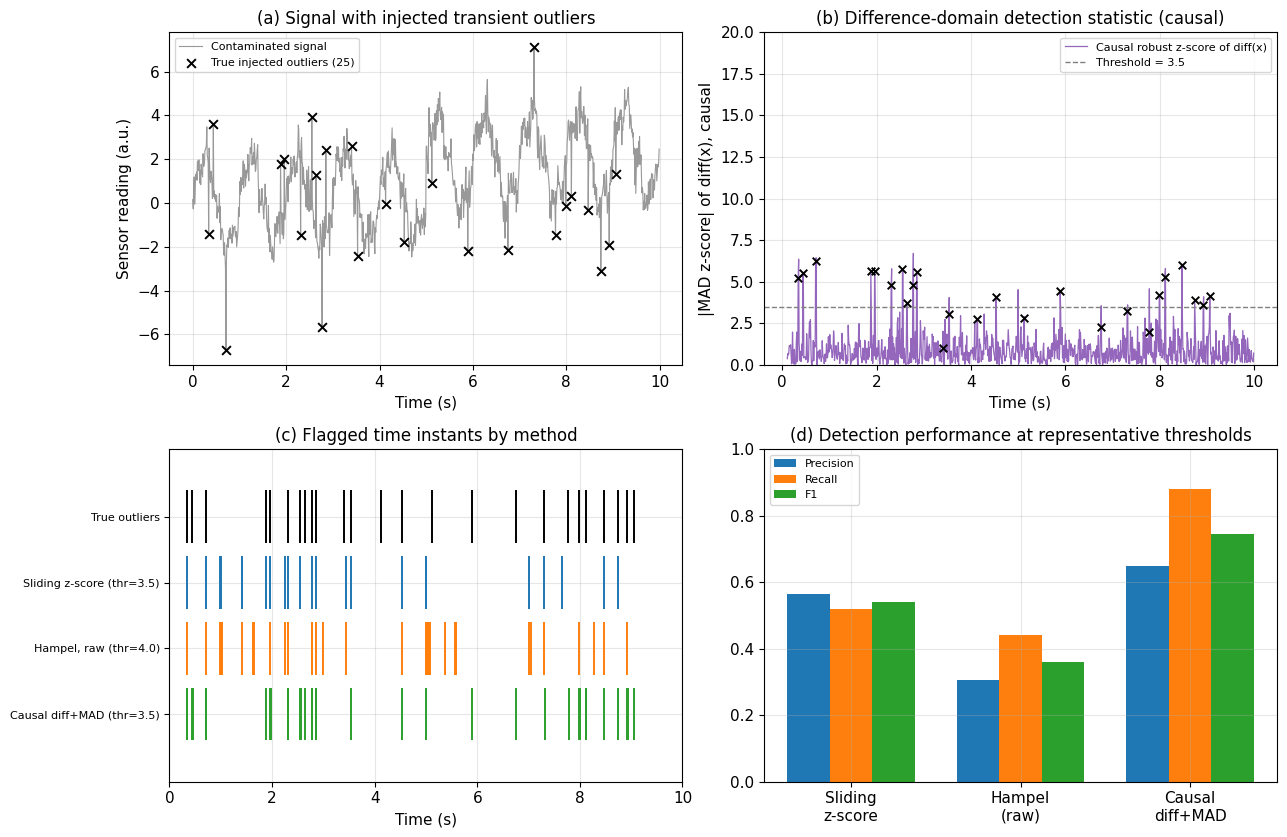

In [9]:
# -- Figure 14.3: outlier detection comparison -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))

ax = axes[0,0]
ax.plot(t_a, contaminated, color='0.6', lw=0.8, label='Contaminated signal')
ax.scatter(t_a[outlier_idx], contaminated[outlier_idx], color='black', marker='x', s=40,
           zorder=5, label=f'True injected outliers ({n_outliers})')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Sensor reading (a.u.)')
ax.set_title('(a) Signal with injected transient outliers'); ax.legend(fontsize=8)

ax = axes[0,1]
d_series = np.diff(contaminated, prepend=contaminated[0])
z_causal = np.full(N_a, np.nan)
for i in range(N_a):
    history = d_series[max(1, i-W_diff):i]
    if len(history) < 10: continue
    med = np.median(history); mad = np.median(np.abs(history-med))
    if mad < 1e-9: continue
    z_causal[i] = abs(d_series[i]-med)/(1.4826*mad)
ax.plot(t_a, z_causal, color='tab:purple', lw=0.9, label='Causal robust z-score of diff(x)')
ax.axhline(3.5, color='gray', ls='--', lw=1, label='Threshold = 3.5')
ax.scatter(t_a[outlier_idx], z_causal[outlier_idx], color='black', marker='x', s=30, zorder=5)
ax.set_ylim(0, 20); ax.set_xlabel('Time (s)'); ax.set_ylabel('|MAD z-score| of diff(x), causal')
ax.set_title('(b) Difference-domain detection statistic (causal)'); ax.legend(fontsize=8)

ax = axes[1,0]
rows = [('True outliers', t_a[outlier_idx], 'black'),
        ('Sliding z-score (thr=3.5)', t_a[np.where(flags_z)[0]], 'tab:blue'),
        ('Hampel, raw (thr=4.0)', t_a[np.where(flags_h)[0]], 'tab:orange'),
        ('Causal diff+MAD (thr=3.5)', t_a[np.where(flags_d)[0]], 'tab:green')]
for i, (name, times, color) in enumerate(rows):
    ax.eventplot([times], lineoffsets=[3-i], linelengths=0.8, colors=color)
ax.set_yticks([3,2,1,0]); ax.set_yticklabels([r[0] for r in rows], fontsize=8)
ax.set_xlabel('Time (s)'); ax.set_xlim(0,10)
ax.set_title('(c) Flagged time instants by method')

ax = axes[1,1]
names_bar = ['Sliding\nz-score', 'Hampel\n(raw)', 'Causal\ndiff+MAD']
res_z, res_h, res_d = evaluate(flags_z, outlier_idx), evaluate(flags_h, outlier_idx), evaluate(flags_d, outlier_idx)
prec = [res_z['precision'], res_h['precision'], res_d['precision']]
rec  = [res_z['recall'], res_h['recall'], res_d['recall']]
f1s  = [res_z['f1'], res_h['f1'], res_d['f1']]
x = np.arange(3); width = 0.25
ax.bar(x-width, prec, width, label='Precision', color='tab:blue')
ax.bar(x, rec, width, label='Recall', color='tab:orange')
ax.bar(x+width, f1s, width, label='F1', color='tab:green')
ax.set_xticks(x); ax.set_xticklabels(names_bar); ax.set_ylim(0,1)
ax.set_title('(d) Detection performance at representative thresholds')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_14_3_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

### Analysis

The causal difference-domain detector is the clear winner: at
threshold 3.5 it reaches precision 0.647 and recall 0.880 (F1 = 0.746),
catching 22 of the 25 injected spikes with 12 false alarms. The two
raw-value detectors do considerably worse at their best operating
points: sliding z-score peaks at F1 = 0.542 (threshold 3.5), and the
Hampel identifier, despite its reputation for robustness, tops out at
F1 = 0.361 (threshold 4.0), with precision below 0.2 at the lower
thresholds (e.g. 81% of its threshold-3.0 flags are false alarms).

The reason is visible in Figure 14.3(a): Signal A moves by roughly
2-3 units peak-to-peak within a single oscillation cycle, so a trailing
window computing $\mu_w,\sigma_w$ or $\mathrm{median}_w,\mathrm{MAD}_w$
on the *raw value* is measuring a mixture of genuine signal curvature
and noise, not noise alone. An outlier of 4-8$\sigma_n$ has to compete
against a window statistic already inflated by the signal's own motion,
which is why both raw-value detectors need a fairly high threshold
before precision becomes usable, and even then keep missing roughly half
the true spikes. The first difference of the signal, by contrast, stays
comparatively small from sample to sample even while the signal's
absolute level swings widely: Figure 14.3(b) shows the outliers standing
out as clean, isolated peaks against a flat background. Differencing
does not remove oscillatory content outright -- how much of a given tone
survives depends on its frequency relative to the sampling rate -- but
for Signal A's comparatively slow 1 and 4 Hz tones sampled at 100 Hz, it
strongly attenuates the smooth, low-frequency variation and leaves
mostly noise plus the two large transients (entry and exit) that a
spike produces in the difference series. Using a trailing window of past
differences, rather than statistics from the whole record, costs almost
nothing here: the causal version's F1 (0.746) is close to what the
same idea achieves with full-record statistics, confirming the
difference-domain approach itself is doing the work, not the
non-causal shortcut.

That two-edges property is also the difference detector's main
limitation: because a single-sample spike shows up as *two* large
excursions in $d[n]$, a fraction of its false positives are really
shadow detections of a true spike's second edge rather than independent
errors, which is part of why its precision stays below 0.7 even at its
best recall. A practical deployment would de-duplicate flags that fall
within one or two samples of each other, folding each spike's two edges
into a single reported event.

**Challenge tasks**

1. Add a de-duplication step that merges any two flagged samples within
   2 samples of each other into a single detection, and recompute the
   results table for the causal difference detector. How much does
   precision improve?
2. Reduce the outlier magnitude range from 4-8$\sigma_n$ to 2-4$\sigma_n$
   and repeat the comparison. Does the ranking of the three methods
   change?
3. Apply the Hampel identifier to the *median-filtered residual*
   ($x[n]$ minus the Exercise 14.1 median filter output) instead of to
   the raw signal, and compare its performance against the causal
   difference-domain detector.
4. Combine outlier detection with Exercise 14.1: once a sample is
   flagged, replace it with the median-filter estimate before it reaches
   any downstream filter, and measure whether this improves the SMA and
   Kalman RMSE figures from Exercise 14.1 on the contaminated signal.

---
## Exercise 14.4 — Reducing What Gets Transmitted: Compression and Feature Extraction

### Background

Filtering and outlier rejection improve the *quality* of what a node
measures; this final exercise looks at reducing the *quantity* of what
it has to send. Radio airtime is usually the single most expensive
resource on a battery-powered node (Chapter 20), so any algorithm that
lets the node transmit fewer bytes for the same useful information pays
for itself directly in battery life. Two very different strategies are
compared, and both are checked more carefully than a first glance
invites.

**Send-on-delta** transmits a new sample only when it differs from the
last transmitted value by more than a threshold. Reconstructing the
signal between transmissions can be done two ways with very different
implications: **zero-order hold (ZOH)**, which simply repeats the last
received value until the next one arrives, is *causal* — a receiver can
compute it the instant a new sample lands, with no knowledge of the
future. **Linear interpolation** draws a straight line between two
consecutive transmitted samples, which requires already knowing the
*next* transmitted value — it is a *retrospective* reconstruction,
usable for archival or offline analysis but not for an immediate,
real-time display or control loop.

**Feature extraction** takes a different approach entirely: instead of
transmitting samples at all, the node computes a small, fixed-size
summary of a whole window of data — here, energy in a few frequency
bands, via a **properly normalized power spectral density**
(`scipy.signal.periodogram`, Section 14.2.4) — and transmits only that
summary.

### Part A: send-on-delta on a slowly varying signal

Applied to the SMA-denoised version of Signal A from Exercise 14.1, at
six thresholds, with both reconstruction methods.

In [10]:
# -- Exercise 14.4a: send-on-delta compression, ZOH vs. linear ------------
denoised_a = sma_causal(raw_a, 3)   # reuse the Exercise 14.1 SMA filter

def send_on_delta(x, threshold):
    idx = [0]; last = x[0]
    for i in range(1, len(x)):
        if abs(x[i]-last) > threshold:
            idx.append(i); last = x[i]
    return np.array(idx)

def reconstruct_zoh(x, idx, n):
    """Causal: holds the last transmitted value. Computable in real time."""
    y = np.empty(n)
    for k in range(len(idx)-1):
        y[idx[k]:idx[k+1]] = x[idx[k]]
    y[idx[-1]:] = x[idx[-1]]
    return y

def reconstruct_linear(x, idx, n):
    """Retrospective: needs the NEXT transmitted sample. Offline/archival use only."""
    return np.interp(np.arange(n), idx, x[idx])

thresholds = [0.05, 0.10, 0.20, 0.30, 0.50, 0.80]
comp_results = []
raw_stream_bytes = N_a * 2   # a regularly-clocked int16 stream needs no per-sample timestamp
print(f"{'thr':>6s}{'n_sent':>8s}{'frac(%)':>9s}{'RMSE(ZOH)':>11s}{'RMSE(lin)':>11s}"
      f"{'value-only(%)':>15s}{'value+2B-ts(%)':>16s}")
for thr in thresholds:
    idx = send_on_delta(denoised_a, thr)
    y_zoh = reconstruct_zoh(denoised_a, idx, N_a)
    y_lin = reconstruct_linear(denoised_a, idx, N_a)
    frac = len(idx)/N_a*100
    value_only_pct = len(idx)*2 / raw_stream_bytes * 100        # int16 value only
    value_ts_pct   = len(idx)*(2+2) / raw_stream_bytes * 100    # + uint16 delta-timestamp
    comp_results.append((thr, len(idx), frac, rmse(y_zoh,denoised_a), rmse(y_lin,denoised_a),
                          value_only_pct, value_ts_pct))
    print(f"{thr:6.2f}{len(idx):8d}{frac:9.2f}{rmse(y_zoh,denoised_a):11.4f}{rmse(y_lin,denoised_a):11.4f}"
          f"{value_only_pct:15.1f}{value_ts_pct:16.1f}")

   thr  n_sent  frac(%)  RMSE(ZOH)  RMSE(lin)  value-only(%)  value+2B-ts(%)
  0.05     853    85.30     0.0113     0.0517           85.3           170.6
  0.10     710    71.00     0.0309     0.0803           71.0           142.0
  0.20     482    48.20     0.0824     0.1384           48.2            96.4
  0.30     347    34.70     0.1295     0.1949           34.7            69.4
  0.50     200    20.00     0.2338     0.2913           20.0            40.0
  0.80     104    10.40     0.3706     0.4559           10.4            20.8


### Part B: FFT band-energy features on a vibration signal

Applied to two synthetic 1-second windows of Signal B (500 Hz): one
"healthy" window matching Exercise 14.2's parameters ($a_2=1.0$), and
one "developing fault" window in which the 30 Hz harmonic amplitude has
grown to $a_2=1.8$ — a simplified proxy for the kind of harmonic growth
that accompanies developing bearing wear or misalignment in rotating
machinery.

In [11]:
# -- Exercise 14.4b: FFT band-energy features, properly normalized PSD ----
t_win, healthy, _    = generate_signal_b(seed=1, duration=1.0, a2=1.0)
_,     developing, _ = generate_signal_b(seed=2, duration=1.0, a2=1.8)
N_win = len(t_win)

def band_energy_features(x, fs, bands):
    """Band powers from a correctly scaled one-sided periodogram (Hann
    window, 'density' scaling). sum(psd)*df recovers signal variance
    (Parseval), so these are true power estimates, not arbitrary units."""
    freqs, psd = periodogram(x, fs=fs, window='hann', detrend='constant', scaling='density')
    df = freqs[1] - freqs[0]
    feats = np.array([psd[(freqs>=lo)&(freqs<hi)].sum()*df for lo, hi in bands])
    dom_freq = freqs[np.argmax(psd[1:])+1]     # skip the DC bin
    return feats, dom_freq, freqs, psd

bands = [(5,20), (20,40), (40,60), (60,100)]
feats_h, dom_h, freqs_w, psd_h = band_energy_features(healthy, 500.0, bands)
feats_f, dom_f, freqs_w, psd_f = band_energy_features(developing, 500.0, bands)

print("Band powers (a.u.^2) -- healthy:   ", np.round(feats_h, 3))
print("Band powers (a.u.^2) -- developing:", np.round(feats_f, 3))
print(f"Relative change, 20-40 Hz band: {(feats_f[1]-feats_h[1])/feats_h[1]*100:.1f}%")
print(f"Dominant frequency -- healthy: {dom_h:.1f} Hz, developing: {dom_f:.1f} Hz "
      "(unchanged -- the fundamental still dominates)")

raw_bytes = N_win*2                       # int16 per raw sample
feat_bytes = (len(bands)+1)*4             # float32 per feature (4 band powers + dominant f)
print(f"\nRaw window: {N_win} samples x 2 B = {raw_bytes} B/window")
print(f"Feature vector: {len(bands)+1} floats x 4 B = {feat_bytes} B/window")
print(f"Reduction factor: {raw_bytes/feat_bytes:.1f}x")

Band powers (a.u.^2) -- healthy:    [2.011e+00 4.960e-01 1.126e+00 1.000e-03]
Band powers (a.u.^2) -- developing: [2.002e+00 1.624e+00 1.148e+00 2.000e-03]
Relative change, 20-40 Hz band: 227.2%
Dominant frequency -- healthy: 15.0 Hz, developing: 15.0 Hz (unchanged -- the fundamental still dominates)

Raw window: 500 samples x 2 B = 1000 B/window
Feature vector: 5 floats x 4 B = 20 B/window
Reduction factor: 50.0x


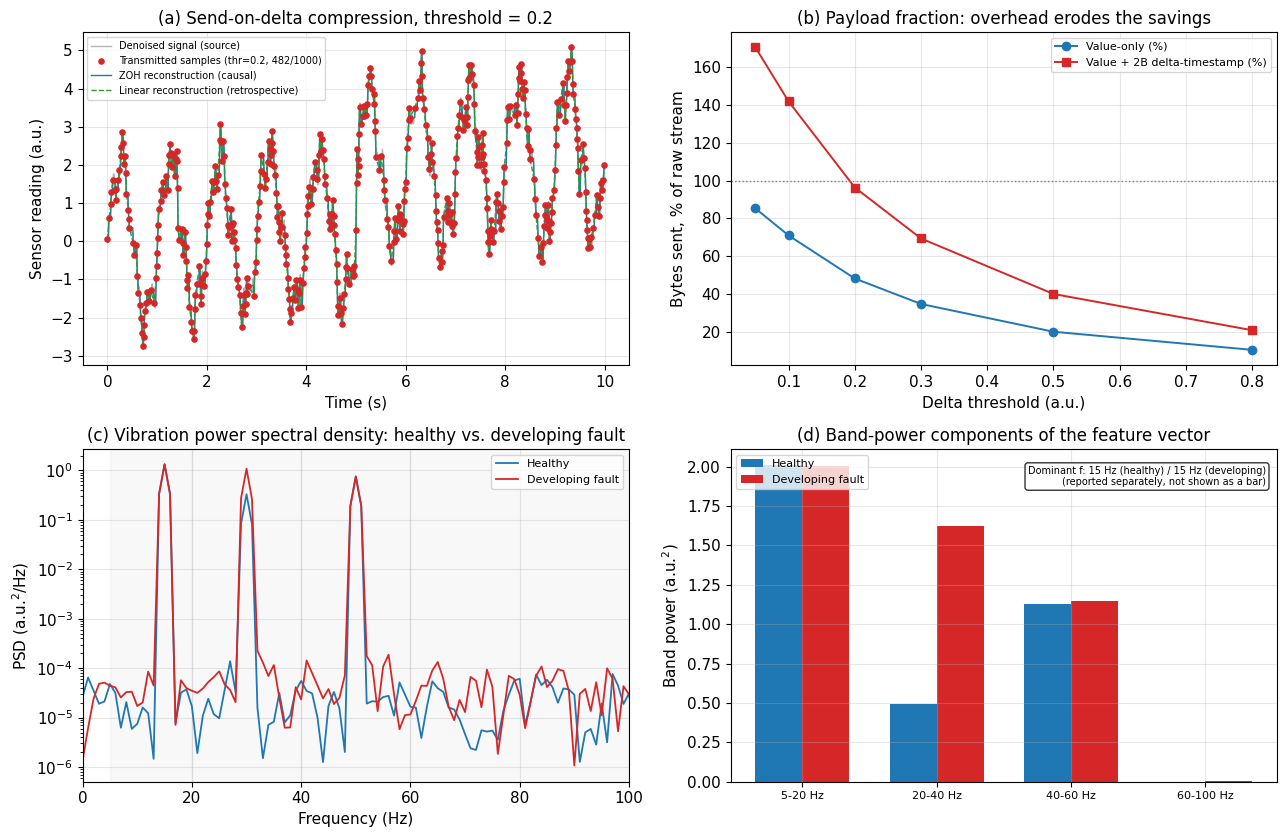

In [12]:
# -- Figure 14.4: compression and feature extraction ------------------------
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))

ax = axes[0,0]
idx_demo = send_on_delta(denoised_a, 0.2)
ax.plot(t_a, denoised_a, color='0.7', lw=1.0, label='Denoised signal (source)')
ax.scatter(t_a[idx_demo], denoised_a[idx_demo], color='tab:red', s=14, zorder=5,
           label=f'Transmitted samples (thr=0.2, {len(idx_demo)}/{N_a})')
ax.plot(t_a, reconstruct_zoh(denoised_a, idx_demo, N_a), color='tab:blue', lw=1.0,
        label='ZOH reconstruction (causal)')
ax.plot(t_a, reconstruct_linear(denoised_a, idx_demo, N_a), color='tab:green', lw=1.0,
        ls='--', label='Linear reconstruction (retrospective)')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Sensor reading (a.u.)')
ax.set_title('(a) Send-on-delta compression, threshold = 0.2'); ax.legend(fontsize=7)

ax = axes[0,1]
thr_arr = np.array([r[0] for r in comp_results])
frac_arr = np.array([r[2] for r in comp_results])
vts_arr  = np.array([r[6] for r in comp_results])
ax.plot(thr_arr, frac_arr, 'o-', color='tab:blue', label='Value-only (%)')
ax.plot(thr_arr, vts_arr, 's-', color='tab:red', label='Value + 2B delta-timestamp (%)')
ax.axhline(100, color='gray', ls=':', lw=1)
ax.set_xlabel('Delta threshold (a.u.)'); ax.set_ylabel('Bytes sent, % of raw stream')
ax.set_title('(b) Payload fraction: overhead erodes the savings')
ax.legend(fontsize=8)

ax = axes[1,0]
ax.semilogy(freqs_w, psd_h+1e-6, color='tab:blue', lw=1.3, label='Healthy')
ax.semilogy(freqs_w, psd_f+1e-6, color='tab:red', lw=1.3, label='Developing fault')
for lo, hi in bands:
    ax.axvspan(lo, hi, alpha=0.05, color='gray')
ax.set_xlim(0, 100); ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('PSD (a.u.$^2$/Hz)')
ax.set_title('(c) Vibration power spectral density: healthy vs. developing fault')
ax.legend(fontsize=8)

ax = axes[1,1]
band_labels = [f'{lo}-{hi} Hz' for lo, hi in bands]
xpos = np.arange(len(bands)); width = 0.35
ax.bar(xpos-width/2, feats_h, width, color='tab:blue', label='Healthy')
ax.bar(xpos+width/2, feats_f, width, color='tab:red', label='Developing fault')
ax.set_xticks(xpos); ax.set_xticklabels(band_labels, fontsize=8)
ax.set_ylabel('Band power (a.u.$^2$)')
ax.set_title('(d) Band-power components of the feature vector')
ax.text(0.98, 0.95, f'Dominant f: {dom_h:.0f} Hz (healthy) / {dom_f:.0f} Hz (developing)\n(reported separately, not shown as a bar)',
        transform=ax.transAxes, ha='right', va='top', fontsize=7,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('fig_14_4_compression_features.png', dpi=150, bbox_inches='tight')
plt.show()

### Analysis

Send-on-delta behaves as expected in isolation: a tight threshold of
0.05 still transmits 85% of the samples, since Signal A keeps moving
almost every sample and there is little redundancy to exploit at that
resolution, while a threshold of 0.80 reduces that to 10%. But
Figure 14.4(b) makes a point easy to miss if only the raw sample count
is reported: an irregularly timed sample is worthless without knowing
*when* it was taken, so a realistic payload needs a timestamp (or
delta-time) alongside the value. Adding a modest 2-byte delta-timestamp
to each event roughly doubles its size, and at threshold 0.2 that turns
a seemingly attractive 48% "compression" into 96% of the original
stream's bytes — essentially no saving at all once overhead is
counted honestly. Only at more aggressive thresholds (0.5 and above)
does send-on-delta still win decisively (40% of raw bytes, including
overhead, at threshold 0.5). The lesson is not that send-on-delta is a
bad idea, but that a "compression ratio" quoted as a bare sample-count
fraction, without a payload model, overstates the real saving.

The ZOH-vs-linear comparison in Table 14.4a produces a mild surprise:
causal ZOH reconstruction achieves a *lower* RMSE against the source
signal than the retrospective linear interpolation at every threshold
tested (e.g. 0.082 vs. 0.138 at threshold 0.2). This is not a general
law about ZOH being "better" — it follows from how send-on-delta
chooses its trigger points. Because Signal A oscillates, the true path
between two consecutive triggers is often *not* monotonic (it curves
through a peak or trough), and linear interpolation's straight-line
assumption is violated exactly there, while ZOH's "hold the last known
value" assumption carries no such expectation and is not penalized by
it. The practical point is that neither reconstruction method should be
assumed superior without testing it against the specific signal and
triggering scheme in use — and only ZOH is available at all if the
reconstruction has to happen in real time.

Feature extraction plays a different game entirely, and Figure 14.4(c)-(d)
shows it paying off clearly for this oscillatory signal. Transmitting
four band powers and a dominant frequency instead of 500 raw samples is
a 50x reduction in bytes per window (20 B vs. 1000 B), and the 20-40 Hz
band power grows by 227% between the healthy and developing-fault
windows — a clear, machine-readable signal that something in the
mechanical spectrum has changed — while the dominant frequency alone
(still 15 Hz in both cases) would have missed the change entirely. The
central design lesson is that the right choice of feature captures the
change that matters, and a feature that happens to be cheap to compute
is not automatically a feature that happens to be informative.

Neither technique is a universal answer. Send-on-delta preserves
waveform shape (with the ZOH/linear trade-off just described), useful
when the actual signal shape may need inspecting later. Feature
extraction discards the waveform entirely and keeps only what a
specific analysis was designed to detect; if a fault develops in a
frequency band the feature set does not cover, the compressed
representation cannot answer that need retroactively. A practical
system often runs both: a cheap on-board feature extractor flags
candidate events in real time, while the node stores, and only rarely
transmits, short raw-waveform captures around any window with an
unusual feature vector.

**Challenge tasks**

1. Apply send-on-delta directly to the raw (unfiltered) Signal A instead
   of its SMA-denoised version. How much does measurement noise alone
   inflate the number of samples transmitted at a given threshold, once
   the 2-byte timestamp overhead is included?
2. Extend the feature vector in Part B with the spectral centroid
   (defined in Theoretical Foundations, Section 14.2.4) and check
   whether it adds separating power beyond the four band powers
   already used. Then compare a *dominant-frequency-only*
   send-on-delta track against a *20-40 Hz band-power* track for the
   healthy-to-developing-fault transition: which one would actually let
   a monitoring node detect the change, and why does the answer matter
   more than the byte count of either track?
3. Using the LoRaWAN time-on-air formula from Chapter 20, estimate the
   airtime cost of transmitting the 20 B feature vector once per second
   at SF7, including packet overhead. Then check whether transmitting
   the full 1000 B raw waveform once per second is even possible as a
   single LoRaWAN packet at that spreading factor, given regional
   payload-size limits — and if not, what that implies for a
   full-waveform fallback strategy.
4. Design a combined pipeline: run send-on-delta, with the 2-byte
   timestamp overhead included, on top of the 20-40 Hz band-power track
   sampled once per second, and estimate the resulting bytes/hour for a
   continuously reporting node.

---
## Summary

| Exercise | Technique | Practical benefit |
|----------|-----------|--------------------|
| 14.1 | Causal SMA, EMA, median, and scalar Kalman denoising | Cuts RMSE substantially on a slowly varying, noisy channel; exposes the steady-state-vs-agility trade-off between recursive and short-window filters |
| 14.2 | Butterworth vs. Chebyshev I IIR low-pass design to spec | Removes an out-of-band interferer that no simple smoother can reliably separate from the signal; shows the order cost of a flat passband and the delay cost of any causal filter |
| 14.3 | Causal sliding z-score, Hampel identifier, and difference-domain MAD detection | Flags transient outliers with measured precision/recall; shows why detecting in the difference domain beats raw-value statistics on a non-stationary signal |
| 14.4 | Send-on-delta compression (ZOH vs. linear reconstruction) and FFT band-power features | Quantifies the airtime/bandwidth cost of raw transmission, including payload overhead, against a feature-based alternative |

Wherever this notebook evaluates deployment behaviour, it uses a
**causal** implementation: the four Exercise 14.1 filters, all three
Exercise 14.3 detectors, and the ZOH reconstruction in Exercise 14.4 use
only current and past samples, as a live streaming device would.
Non-causal operations appear only as explicitly labelled **offline
reference baselines** — `sosfiltfilt`'s zero-phase filtering in Exercise
14.2, and linear interpolation's retrospective reconstruction in
Exercise 14.4 — precisely so that the gap between what an offline
analysis can achieve and what a real-time device can actually deliver is
visible rather than hidden. Together with the anti-aliasing filter
examined in Chapter 13, these four exercises complete the on-board
signal-processing chain introduced in this chapter: acquire, denoise or
frequency-select, reject outliers, and finally reduce what actually
needs to leave the device.